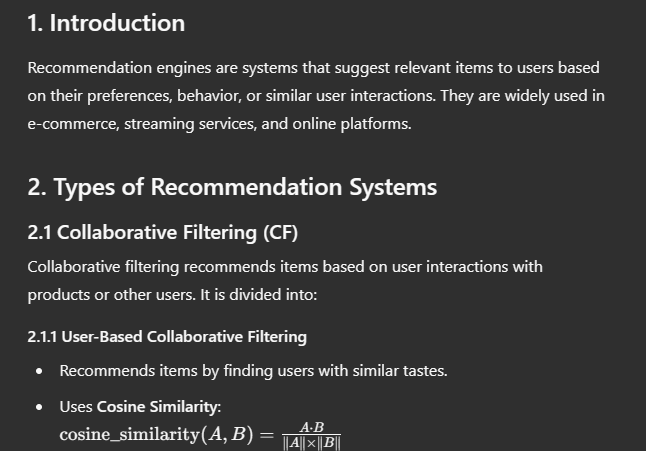

user base

In [1]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

user_item_matrix = np.array([
#item[1, 2, 3, 4] ratings
    [5, 3, 0, 1], # user1
    [4, 0, 4, 1], # user2
    [3, 3, 1, 5]  # user3
])
similarity = cosine_similarity(user_item_matrix)
print(similarity)

[[1.         0.61791438 0.73898843]
 [0.61791438 1.         0.55110708]
 [0.73898843 0.55110708 1.        ]]


similarity of user1 wiht user1, user2 and user3 

In [2]:
similarity[0] 

array([1.        , 0.61791438, 0.73898843])

similarity of user2 with user1 , user2 and user3

In [3]:
similarity[1]

array([0.61791438, 1.        , 0.55110708])

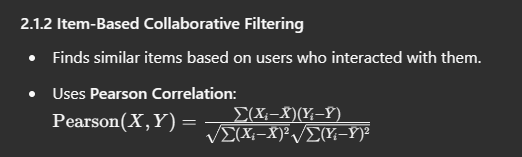

item base

In [4]:
user_item_matrix.T # column = user1, user2, user3 || rows = item1, item2, item3, item4

array([[5, 4, 3],
       [3, 0, 3],
       [0, 4, 1],
       [1, 1, 5]])


Pairwise distance refers to the distance between each pair of points in a dataset. There are several types of pairwise distances, including:

Euclidean distance:  The straight-line distance between two points.

Manhattan distance:  The sum of the absolute differences in their Cartesian coordinates.

Minkowski distance:  A generalization of the Euclidean and Manhattan distances.

Cosine distance:  A measure of the angle between two vectors.

Correlation distance: 

In PySpark, you can calculate pairwise distances using the VectorUDT and Vectors classes from the pyspark.ml.linalg module.

In [5]:
from sklearn.metrics.pairwise import pairwise_distances

Correlation Distance

Correlation distance measures the difference between two vectors in terms of their correlation coefficient. The correlation coefficient measures the strength and direction of the linear relationship between two variables.
Given two vectors x and y, the correlation distance is calculated as:

Calculate the correlation coefficient ρ between x and y:

ρ(x, y) = cov(x, y) / (σx * σy)

where cov(x, y) is the covariance between x and y, and σx and σy are the standard deviations of x and y, respectively.
Calculate the correlation distance d:

d(x, y) = 1 - ρ(x, y)

The correlation distance ranges from 0 (perfect positive correlation) to 2 (perfect negative correlation).
Properties of Correlation Distance
Correlation distance has several important properties:

Symmetry: d(x, y) = d(y, x)

Non-negativity: d(x, y) ≥ 0

Triangle inequality: d(x, z) ≤ d(x, y) + d(y, z)

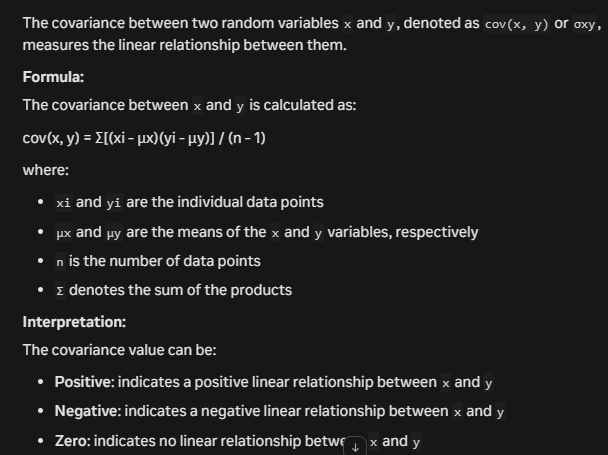

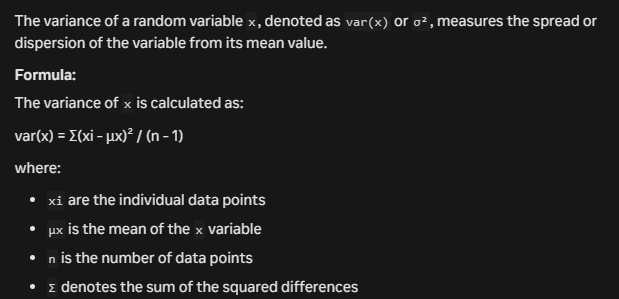

In [6]:
pairwise_distances(user_item_matrix.T, metric='correlation')

array([[0.        , 1.        , 1.24019223, 1.8660254 ],
       [1.        , 0.        , 1.97072534, 0.5       ],
       [1.24019223, 1.97072534, 0.        , 1.2773501 ],
       [1.8660254 , 0.5       , 1.2773501 , 0.        ]])

In [7]:
item_similarity = 1 - pairwise_distances(user_item_matrix.T, metric='correlation')
print(item_similarity)

[[ 1.          0.         -0.24019223 -0.8660254 ]
 [ 0.          1.         -0.97072534  0.5       ]
 [-0.24019223 -0.97072534  1.         -0.2773501 ]
 [-0.8660254   0.5        -0.2773501   1.        ]]


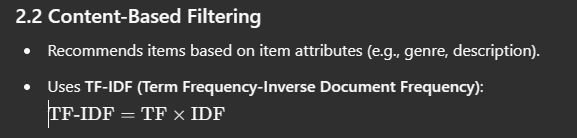

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = ["Action movie with great scenes", "Romantic love story", "Sci-fi adventure"]
vectorizer = TfidfVectorizer()


In [ ]:
#        Action movie with great scenes Romantic love story Sci-fi adventure
# doc 1 : 1      1     1     1     1      0        0   0     0   0   0

In [9]:
vectorizer

TfidfVectorizer()

In [10]:
tfidf_matrix = vectorizer.fit_transform(documents)
print(tfidf_matrix.toarray())

[[0.4472136  0.         0.         0.4472136  0.         0.4472136
  0.         0.4472136  0.         0.         0.4472136 ]
 [0.         0.         0.         0.         0.57735027 0.
  0.57735027 0.         0.         0.57735027 0.        ]
 [0.         0.57735027 0.57735027 0.         0.         0.
  0.         0.         0.57735027 0.         0.        ]]


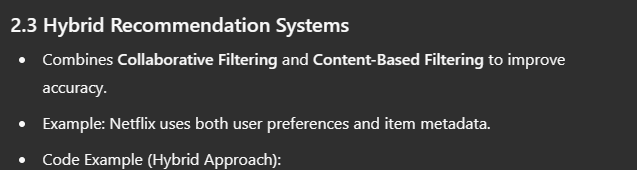

In [13]:
hybrid_scores = 0.5 * similarity + 0.5 * item_similarity.T
print(hybrid_scores)


ValueError: operands could not be broadcast together with shapes (3,3) (4,4) 

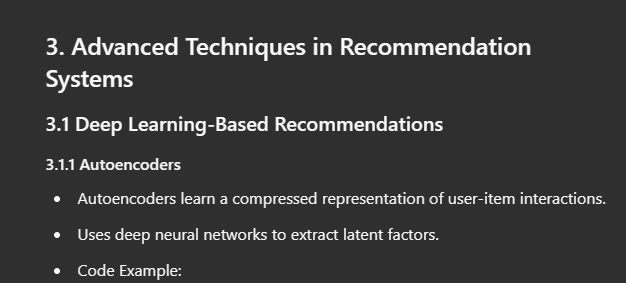

In [14]:
from tensorflow import keras
from tensorflow.keras.layers import Dense
import numpy as np

model = keras.Sequential([
    Dense(64, activation='relu', input_shape=(user_item_matrix.shape[1],)),
    Dense(32, activation='relu'),
    Dense(user_item_matrix.shape[1], activation='sigmoid')
])
model.compile(optimizer='adam', loss='mse')
model.fit(user_item_matrix, user_item_matrix, epochs=10, batch_size=4)

d:\a27_YEARS_OLD\book_recomendation\venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 6.5892
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 6.5199
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 6.4520
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 6.3857
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 6.3204
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 6.2488
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 6.1738
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 6.0998
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 6.0284
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 5.9622


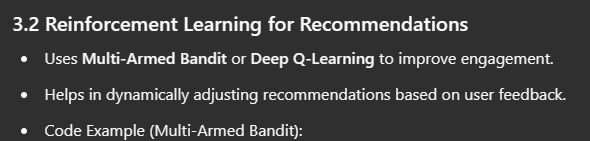

In [16]:
import numpy as np

n_arms = 5
rewards = np.zeros(n_arms)
counts = np.zeros(n_arms)

def select_arm():
    return np.argmax(rewards / (counts + 1e-5))

def update_arm(chosen_arm, reward):
    counts[chosen_arm] += 1
    rewards[chosen_arm] += reward

In [15]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Sample dataset
movies = pd.DataFrame({
    'title': ['Movie A', 'Movie B', 'Movie C'],
    'genre': ['Action', 'Romance', 'Sci-fi']
})

# Compute TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(movies['genre'])

# Compute similarity
similarity_matrix = cosine_similarity(tfidf_matrix)
print(similarity_matrix)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


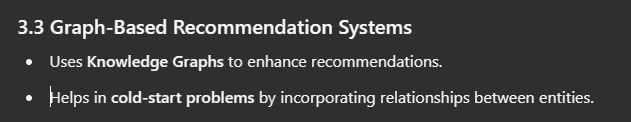

In [18]:
from graphs import Graph, Task
import pandas as pd

# Sample data: Users, Movies, and Ratings
edges = [
    ('User1', 'MovieA', 5),
    ('User1', 'MovieB', 3),
    ('User2', 'MovieA', 4),
    ('User2', 'MovieC', 5),
    ('User3', 'MovieB', 4),
    ('User3', 'MovieC', 2)
]

# Create Graph
G = Graph()
for user, movie, rating in edges:
    G.add_edge(user, movie, weight=rating)

# Function to recommend movies
def recommend_movies(user, top_n=2):
    neighbors = G[user]
    recommendations = sorted(neighbors.items(), key=lambda x: x[1]['weight'], reverse=True)
    return [movie for movie, _ in recommendations[:top_n]]

# Recommend movies for User1
print("Recommended movies for User1:", recommend_movies('User1'))

d:\a27_YEARS_OLD\book_recomendation\venv\Lib\site-packages\Cython\Compiler\Main.py:381: FutureWarning: Cython directive 'language_level' not set, using '3str' for now (Py3). This has changed from earlier releases! File: d:\a27_YEARS_OLD\book_recomendation\venv\Lib\site-packages\graphs\mixins\_betweenness_helper.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)

Error compiling Cython file:
------------------------------------------------------------
...
from libcpp.stack cimport stack
from libcpp.pair cimport pair
from libcpp.queue cimport priority_queue

cdef double INF = float('inf')
ctypedef np.int_t intc
         ^
------------------------------------------------------------

d:\a27_YEARS_OLD\book_recomendation\venv\Lib\site-packages\graphs\mixins\_betweenness_helper.pyx:12:9: 'int_t' is not a type identifier

Error compiling Cython file:
------------------------------------------------------------
...
    for s in range(n):
      pred = sssp(adj, s, sigma, dist, S)
      del

AttributeError: module 'matplotlib' has no attribute 'get_data_path'